# Workload Characterization - Analisi

Analisi dei dati raccolti dalla catena di microservizi `s0 -> s1 -> s2 -> s3`
(muBench su Kubernetes/kind). Il nodo `s2` usa una funzione interna a **coda
pesante** (complessita' ~ Pareto), gli altri nodi hanno service time quasi
deterministico.

Quattro scenari di carico, 3 run ciascuno:

| Scenario | Processo di arrivo | Rate nominale |
|----------|--------------------|---------------|
| low      | Poisson (inter-arrival esponenziali) | 5 req/s  |
| mid      | Poisson              | 20 req/s |
| high     | Poisson              | 50 req/s |
| bursty   | ON-OFF (MMPP-2)      | ~26 req/s eff. |

**Dati disponibili** (come richiesto dalla traccia del progetto):
- *arrival rates* e *response time* -> dai file `result` del Runner
- *queue lengths* -> colonna `pending` dei result
- *service times* per-servizio -> istogrammi Prometheus (bucket fini)
- *CPU/memory* per pod -> CSV campionati durante le campagne

## 1. Setup e caricamento dati

In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, acf

print('Librerie importate correttamente')

DATA = os.path.expanduser('~/Scrivania/uni/spe/ProgettoSPE/data')
SCENARIOS = ['low', 'mid', 'high', 'bursty']
RUNS = [1, 2, 3]

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

Librerie importate correttamente


In [2]:
def load_result(scenario, run):
    path = f'{DATA}/{scenario}/cl-{scenario}-run{run}_workload-{scenario}.txt'
    cols = ['ts_ms', 'latency_ms', 'status', 'processed', 'pending']
    df = pd.read_csv(path, sep=r'\s+', names=cols, engine='python')
    df['scenario'] = scenario
    df['run'] = run
    return df


def load_all_results():
    frames = []
    for scen in SCENARIOS:
        for run in RUNS:
            frames.append(load_result(scen, run))
    return pd.concat(frames, ignore_index=True)


raw = load_all_results()
print(f'Righe totali caricate: {len(raw)}')
print(f'Scenari: {raw.scenario.unique().tolist()}')
print(f'Status presenti: {sorted(raw.status.unique().tolist())}')
raw.head()

Righe totali caricate: 54000
Scenari: ['low', 'mid', 'high', 'bursty']
Status presenti: [200, 500]


,ts_ms,latency_ms,status,processed,pending,scenario,run
0,1788202061125,62,200,1,0,low,1
1,1788202061389,49,200,2,0,low,1
2,1788202061509,51,200,4,1,low,1
3,1788202061524,58,200,4,0,low,1
4,1788202061672,39,200,5,0,low,1


In [3]:
def prepare(df):
    out = []
    for (scen, run), g in df.groupby(['scenario', 'run']):
        g = g.sort_values('ts_ms').reset_index(drop=True)
        g['iat_ms'] = g['ts_ms'].diff()
        out.append(g)
    return pd.concat(out, ignore_index=True)


data = prepare(raw)
err = data[data.status != 200].groupby('scenario').size()
print('Richieste non-200 per scenario (poi escluse):')
print(err if len(err) else 'nessuna')
ok = data[data.status == 200].copy()
print(f'\nRichieste valide (status 200): {len(ok)} su {len(data)}')

Richieste non-200 per scenario (poi escluse):
scenario
bursty    8
high      6
low       1
dtype: int64

Richieste valide (status 200): 53985 su 54000


## 2. Identificazione del transitorio (metodo di Welch)

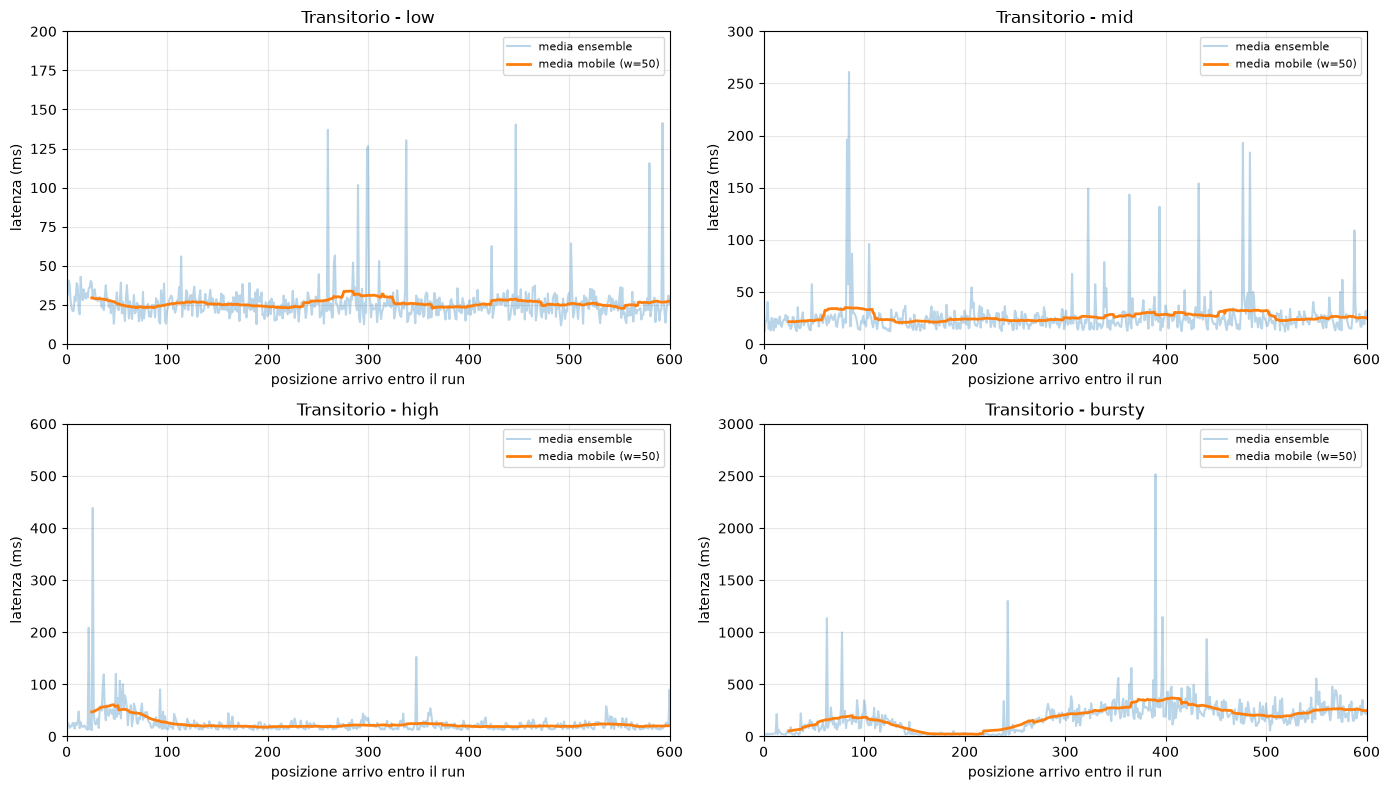

In [4]:
def welch_transient(df, scenario, window=50):
    sub = df[df.scenario == scenario]
    series = []
    for run in RUNS:
        s = sub[sub.run == run].sort_values('ts_ms')['latency_ms'].reset_index(drop=True)
        series.append(s)
    n = min(len(s) for s in series)
    mat = np.vstack([s.values[:n] for s in series])
    ensemble = mat.mean(axis=0)
    kernel = np.ones(window) / window
    smoothed = np.convolve(ensemble, kernel, mode='valid')
    return ensemble, smoothed


ylim_map = {'low': 200, 'mid': 300, 'high': 600, 'bursty': 3000}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, scen in zip(axes.ravel(), SCENARIOS):
    ensemble, smoothed = welch_transient(ok, scen, window=50)
    ax.plot(ensemble, alpha=0.3, label='media ensemble')
    ax.plot(np.arange(len(smoothed)) + 25, smoothed, lw=2, label='media mobile (w=50)')
    ax.set_title(f'Transitorio - {scen}')
    ax.set_xlabel('posizione arrivo entro il run')
    ax.set_ylabel('latenza (ms)')
    ax.set_xlim(0, 600)
    ax.set_ylim(0, ylim_map[scen])
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 2b. Determinazione automatica del punto di taglio (robusta)

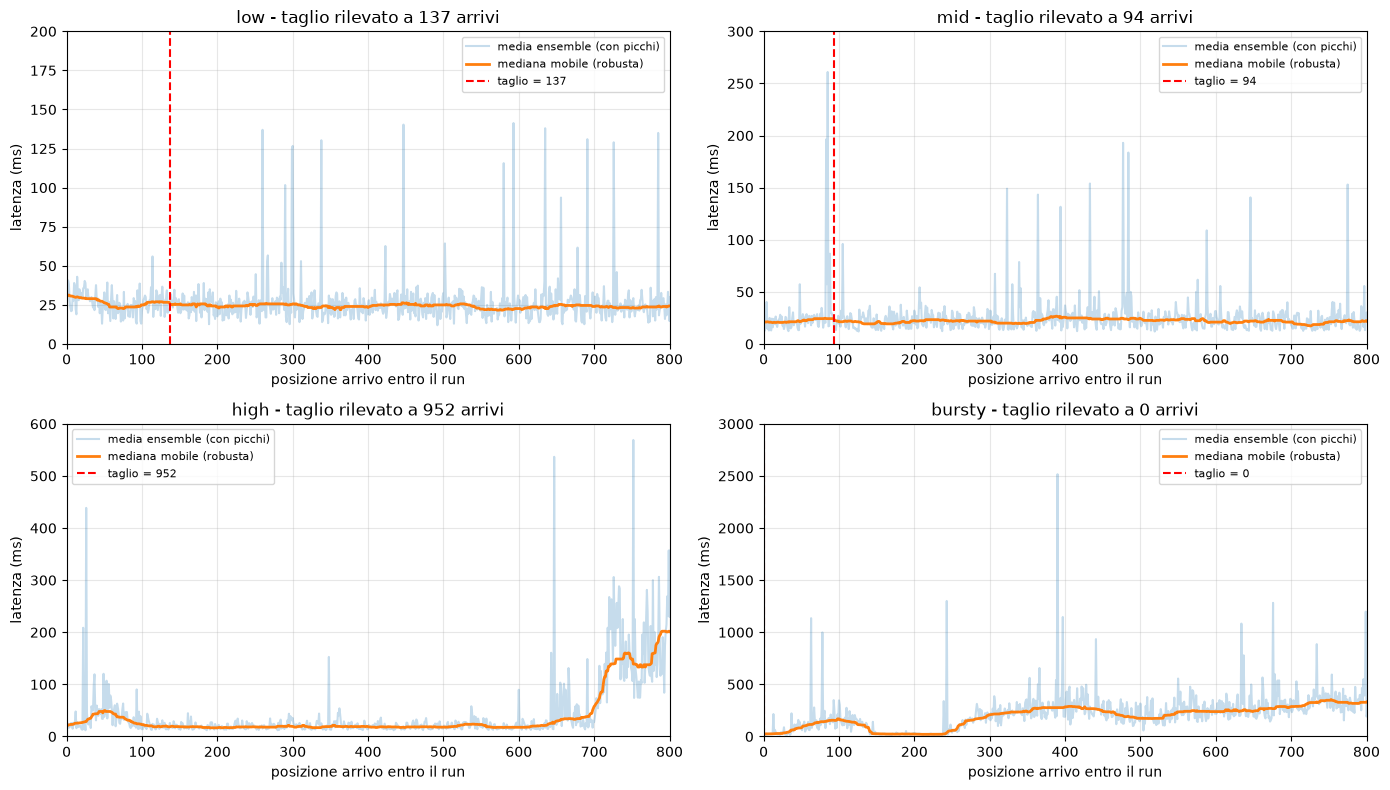

Punto di warm-up rilevato per scenario:
  low     : 137 arrivi
  mid     : 94 arrivi
  high    : 952 arrivi
  bursty  : 0 arrivi


In [5]:
def welch_robust(df, scenario, window=51):
    sub = df[df.scenario == scenario]
    series = []
    for run in RUNS:
        s = sub[sub.run == run].sort_values('ts_ms')['latency_ms'].reset_index(drop=True)
        series.append(s)
    n = min(len(s) for s in series)
    mat = np.vstack([s.values[:n] for s in series])
    ensemble = mat.mean(axis=0)
    med = pd.Series(ensemble).rolling(window, center=True, min_periods=1).median()
    return ensemble, med.values


def detect_warmup(median_curve, rel_tol=0.10, stable_len=100):
    tail_level = np.median(median_curve[len(median_curve) // 3 * 2:])
    if tail_level <= 0:
        return 0
    rel_dev = np.abs(median_curve - tail_level) / tail_level
    below = rel_dev < rel_tol
    run_len = 0
    for i, b in enumerate(below):
        run_len = run_len + 1 if b else 0
        if run_len >= stable_len:
            return i - stable_len + 1
    return 0


fig, axes = plt.subplots(2, 2, figsize=(14, 8))
warmup_per_scenario = {}
for ax, scen in zip(axes.ravel(), SCENARIOS):
    ensemble, med = welch_robust(ok, scen, window=51)
    cut = detect_warmup(med, rel_tol=0.10, stable_len=100)
    warmup_per_scenario[scen] = cut
    ax.plot(ensemble, alpha=0.25, label='media ensemble (con picchi)')
    ax.plot(med, lw=2, color='C1', label='mediana mobile (robusta)')
    ax.axvline(cut, color='red', ls='--', label=f'taglio = {cut}')
    ax.set_title(f'{scen} - taglio rilevato a {cut} arrivi')
    ax.set_xlabel('posizione arrivo entro il run')
    ax.set_ylabel('latenza (ms)')
    ax.set_xlim(0, min(800, len(ensemble)))
    ax.set_ylim(0, ylim_map[scen])
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print('Punto di warm-up rilevato per scenario:')
for scen, cut in warmup_per_scenario.items():
    print(f'  {scen:8}: {cut} arrivi')

In [6]:
MIN_WARMUP = 50
MAX_WARMUP = 300

def drop_warmup_auto(df, warmup_map, min_warmup=MIN_WARMUP, max_warmup=MAX_WARMUP):
    out = []
    for (scen, run), g in df.groupby(['scenario', 'run']):
        g = g.sort_values('ts_ms').reset_index(drop=True)
        cut = min(max(warmup_map.get(scen, 0), min_warmup), max_warmup)
        out.append(g.iloc[cut:])
    return pd.concat(out, ignore_index=True)


clean = drop_warmup_auto(ok, warmup_per_scenario, MIN_WARMUP, MAX_WARMUP)
print(f'Righe dopo scarto warm-up automatico: {len(clean)}')
print('\nRichieste valide per scenario dopo il taglio:')
print(clean.groupby('scenario').size())

Righe dopo scarto warm-up automatico: 52242

Richieste valide per scenario dopo il taglio:
scenario
bursty    14842
high      14094
low        8588
mid       14718
dtype: int64


## 3. Statistiche descrittive e coefficiente di variazione

In [7]:
def describe_metric(df, col):
    rows = []
    for scen in SCENARIOS:
        x = df[df.scenario == scen][col].dropna()
        x = x[x >= 0]
        mean = x.mean(); std = x.std()
        cv = std / mean if mean > 0 else np.nan
        rows.append({'scenario': scen, 'n': len(x), 'media': mean, 'std': std,
                     'CV': cv, 'skew': st.skew(x),
                     'p50': x.quantile(0.50), 'p90': x.quantile(0.90),
                     'p95': x.quantile(0.95), 'p99': x.quantile(0.99), 'max': x.max()})
    return pd.DataFrame(rows).set_index('scenario')


print('INTER-ARRIVAL (ms)')
iat_stats = describe_metric(clean, 'iat_ms')
display(iat_stats.round(3))
print('\nRESPONSE TIME (ms)')
rt_stats = describe_metric(clean, 'latency_ms')
display(rt_stats.round(3))

INTER-ARRIVAL (ms)


,n,media,std,CV,skew,p50,p90,p95,p99,max
scenario,,,,,,,,,,
low,8588,200.166,202.162,1.010,2.005,136.0,469.0,574.0,942.0,1595.0
mid,14718,51.734,51.679,0.999,1.979,36.0,119.0,156.0,244.0,486.0
high,14094,23.934,32.761,1.369,1.710,6.0,82.0,90.0,104.0,309.0
bursty,14842,38.660,128.844,3.333,8.624,9.0,78.0,98.0,662.0,2161.0



RESPONSE TIME (ms)


,n,media,std,CV,skew,p50,p90,p95,p99,max
scenario,,,,,,,,,,
low,8588,25.980,23.706,0.912,10.758,23.0,37.0,39.00,69.13,445
mid,14718,24.058,27.380,1.138,14.209,18.0,36.0,39.00,78.83,875
high,14094,349.072,417.445,1.196,12.360,297.0,594.0,706.00,1117.84,10907
bursty,14842,171.250,276.294,1.613,10.318,38.0,430.0,552.95,859.36,8604


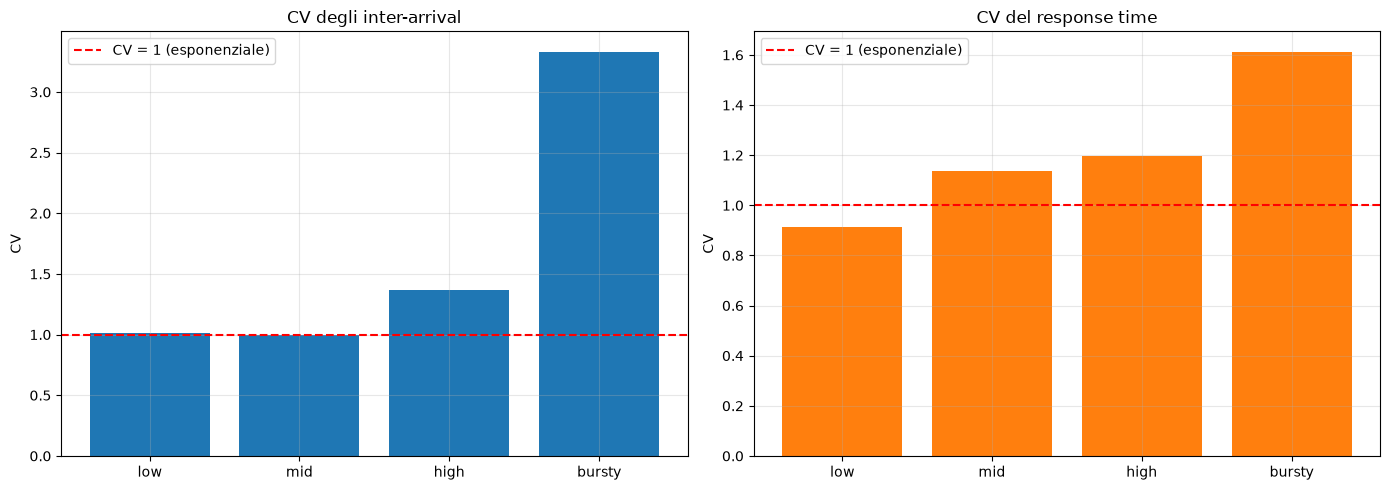

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(SCENARIOS))
ax1.bar(x, iat_stats['CV'], color='C0')
ax1.axhline(1.0, color='red', ls='--', label='CV = 1 (esponenziale)')
ax1.set_xticks(x); ax1.set_xticklabels(SCENARIOS)
ax1.set_title('CV degli inter-arrival'); ax1.set_ylabel('CV'); ax1.legend()
ax2.bar(x, rt_stats['CV'], color='C1')
ax2.axhline(1.0, color='red', ls='--', label='CV = 1 (esponenziale)')
ax2.set_xticks(x); ax2.set_xticklabels(SCENARIOS)
ax2.set_title('CV del response time'); ax2.set_ylabel('CV'); ax2.legend()
plt.tight_layout(); plt.show()

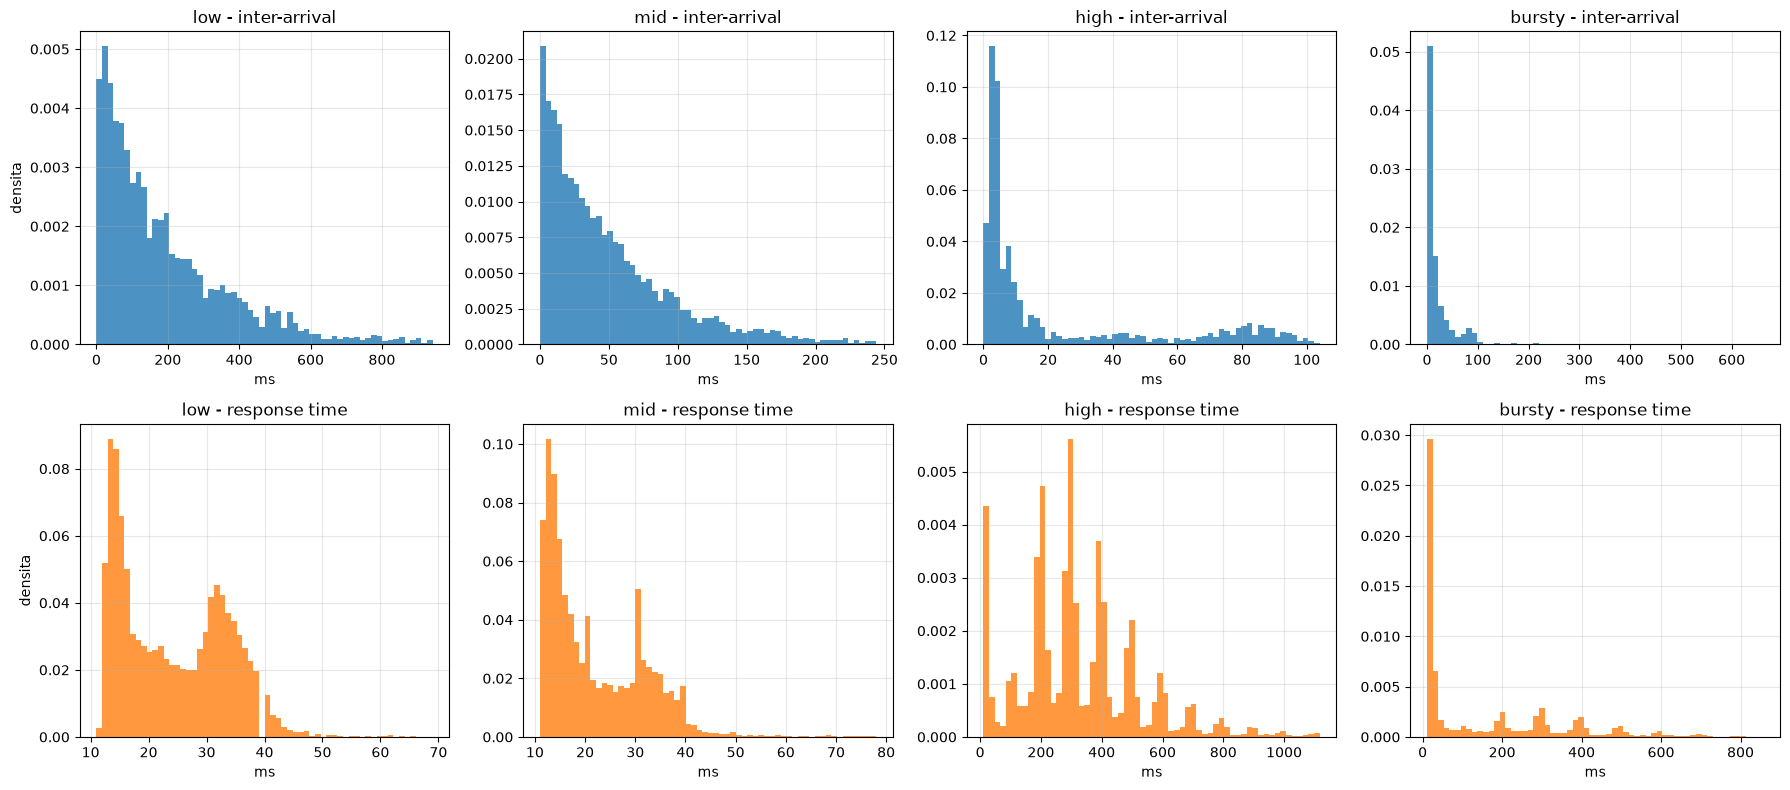

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for j, scen in enumerate(SCENARIOS):
    sub = clean[clean.scenario == scen]
    iat = sub['iat_ms'].dropna()
    iat = iat[(iat >= 0) & (iat <= iat.quantile(0.99))]
    axes[0, j].hist(iat, bins=60, color='C0', alpha=0.8, density=True)
    axes[0, j].set_title(f'{scen} - inter-arrival'); axes[0, j].set_xlabel('ms')
    rt = sub['latency_ms']; rt = rt[rt <= rt.quantile(0.99)]
    axes[1, j].hist(rt, bins=60, color='C1', alpha=0.8, density=True)
    axes[1, j].set_title(f'{scen} - response time'); axes[1, j].set_xlabel('ms')
axes[0, 0].set_ylabel('densita'); axes[1, 0].set_ylabel('densita')
plt.tight_layout(); plt.show()

## 4. Caratterizzazione del processo di arrivo: fitting e test

> **Nota sul K-S con grandi campioni.** Il test diventa ipersensibile: rifiuta
> l'ipotesi nulla anche per deviazioni minime. Si legge quindi la **statistica D**
> (distanza massima) piu' del p-value, affiancata a QQ-plot e confronto AIC.

In [10]:
rows = []
for scen in SCENARIOS:
    x = clean[clean.scenario == scen]['iat_ms'].dropna()
    x = x[x >= 0].values
    loc, scale = st.expon.fit(x, floc=0)
    D, p = st.kstest(x, 'expon', args=(0, scale))
    rows.append({'scenario': scen, 'n': len(x), 'scala_exp (media)': scale,
                 'KS_D': D, 'KS_pvalue': p,
                 'compatibile_exp (D<0.05)': 'si' if D < 0.05 else 'no'})
ks_iat = pd.DataFrame(rows).set_index('scenario')
print('Fit esponenziale e test K-S sugli INTER-ARRIVAL:')
display(ks_iat.round(4))

Fit esponenziale e test K-S sugli INTER-ARRIVAL:


,n,scala_exp (media),KS_D,KS_pvalue,compatibile_exp (D<0.05)
scenario,,,,,
low,8588,200.1662,0.0144,0.0571,si
mid,14718,51.7335,0.0215,0.0000,si
high,14094,23.9343,0.2886,0.0000,no
bursty,14842,38.6602,0.3119,0.0000,no


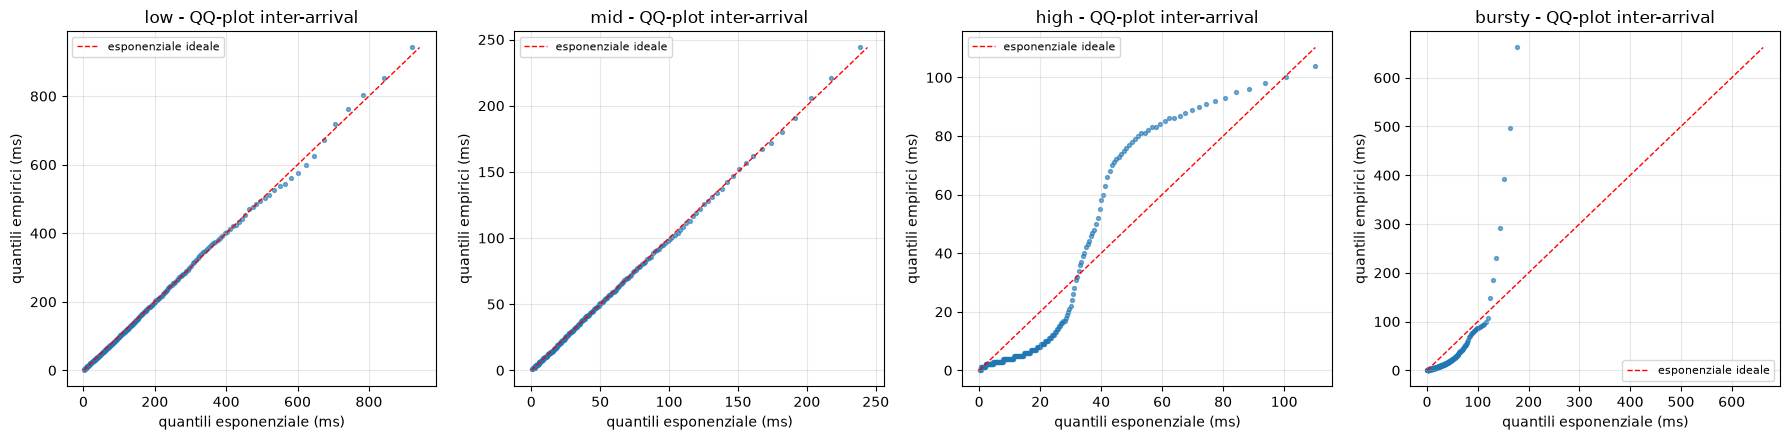

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, scen in zip(axes, SCENARIOS):
    x = clean[clean.scenario == scen]['iat_ms'].dropna()
    x = x[x >= 0].values
    scale = x.mean()
    probs = np.linspace(0.01, 0.99, 200)
    theo = st.expon.ppf(probs, scale=scale)
    emp = np.quantile(x, probs)
    ax.scatter(theo, emp, s=8, alpha=0.6)
    lim = max(theo.max(), emp.max())
    ax.plot([0, lim], [0, lim], 'r--', lw=1, label='esponenziale ideale')
    ax.set_title(f'{scen} - QQ-plot inter-arrival')
    ax.set_xlabel('quantili esponenziale (ms)'); ax.set_ylabel('quantili empirici (ms)')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 4b. Fitting di distribuzioni candidate sul response time (confronto AIC)

In [12]:
CANDIDATES = {'esponenziale': st.expon, 'lognormale': st.lognorm,
              'weibull': st.weibull_min, 'pareto/lomax': st.lomax}

def aic(logL, k):
    return 2 * k - 2 * logL

def fit_candidates(x):
    x = x[x > 0]
    out = []
    for name, dist in CANDIDATES.items():
        try:
            params = dist.fit(x, floc=0)
        except Exception:
            params = dist.fit(x)
        logL = np.sum(dist.logpdf(x, *params))
        D, p = st.kstest(x, dist.name, args=params)
        out.append({'dist': name, 'AIC': aic(logL, len(params)), 'KS_D': D,
                    'params': tuple(np.round(params, 4))})
    return pd.DataFrame(out).set_index('dist').sort_values('AIC')

for scen in SCENARIOS:
    print(f'RESPONSE TIME - {scen}  (miglior fit = AIC piu\' basso)')
    display(fit_candidates(clean[clean.scenario == scen]['latency_ms'].astype(float).values).round(3))

RESPONSE TIME - low  (miglior fit = AIC piu' basso)


,AIC,KS_D,params
dist,,,
lognormale,64518.947,0.111,"(0.4547, 0.0, 22.7624)"
weibull,70294.903,0.234,"(1.4835, 0.0, 29.0447)"
esponenziale,73127.599,0.367,"(0.0, 25.9796)"
pareto/lomax,73129.599,0.367,"(11619904754053.314, 0.0, 301880746329083.2)"


RESPONSE TIME - mid  (miglior fit = AIC piu' basso)


,AIC,KS_D,params
dist,,,
lognormale,108318.881,0.132,"(0.4638, 0.0, 20.6766)"
weibull,119679.836,0.280,"(1.3666, 0.0, 26.6907)"
pareto/lomax,123033.168,0.391,"(66.7235, 0.0, 1579.7944)"
esponenziale,123060.523,0.387,"(0.0, 24.0582)"


RESPONSE TIME - high  (miglior fit = AIC piu' basso)


,AIC,KS_D,params
dist,,,
weibull,192382.286,0.158,"(1.1923, 0.0, 372.1293)"
pareto/lomax,193176.345,0.224,"(38.8336, 0.0, 13180.0996)"
esponenziale,193240.572,0.217,"(0.0, 349.0719)"
lognormale,194714.654,0.195,"(0.9927, 0.0, 243.6967)"


RESPONSE TIME - bursty  (miglior fit = AIC piu' basso)


,AIC,KS_D,params
dist,,,
lognormale,177608.248,0.168,"(1.4359, 0.0, 66.8466)"
pareto/lomax,179424.012,0.158,"(1.3806, 0.0, 103.8015)"
weibull,179513.890,0.183,"(0.7351, 0.0, 138.8125)"
esponenziale,182356.583,0.303,"(0.0, 171.2504)"


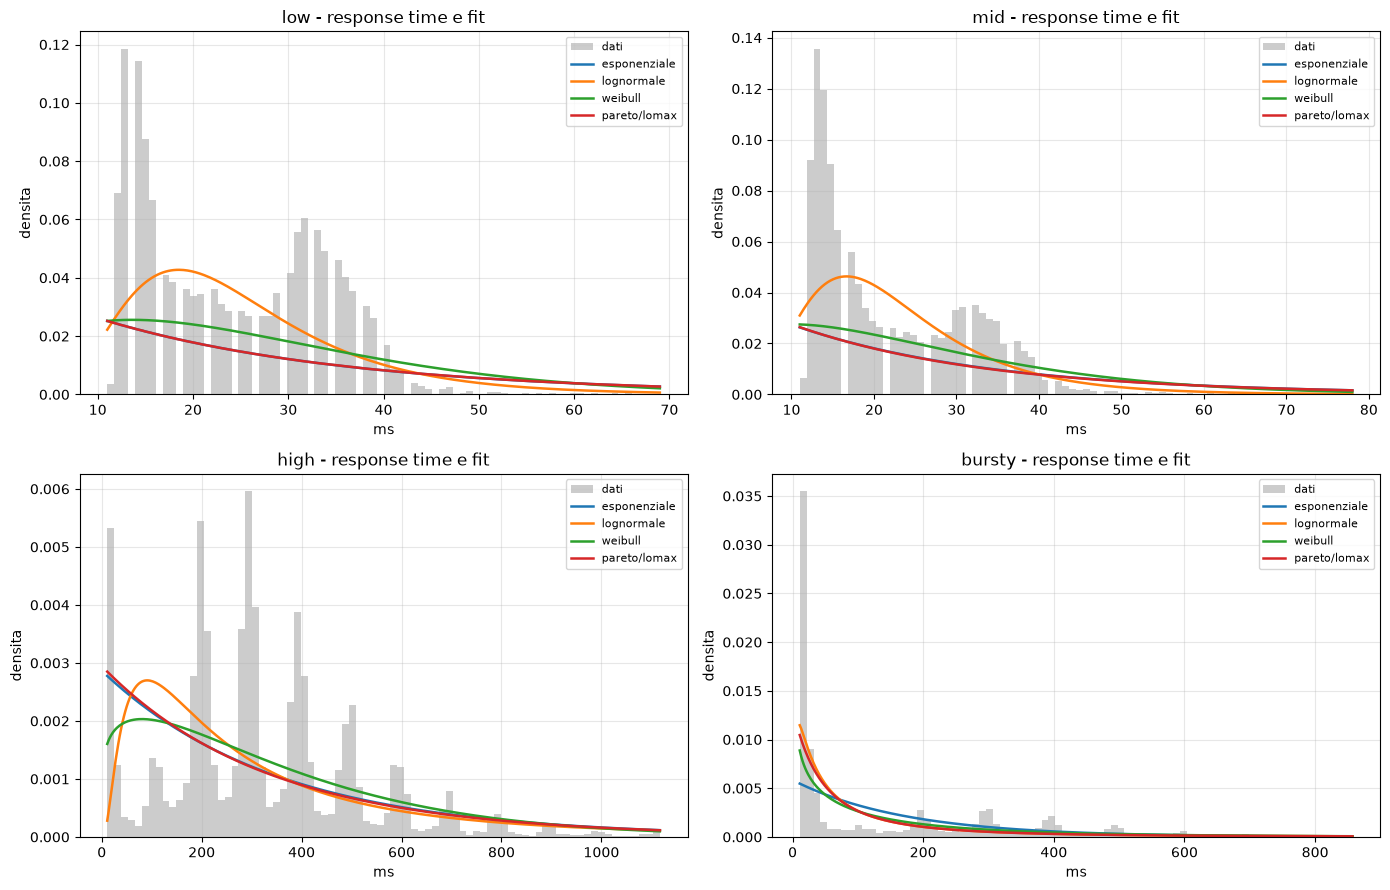

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, scen in zip(axes.ravel(), SCENARIOS):
    x = clean[clean.scenario == scen]['latency_ms'].astype(float).values
    x = x[x > 0]
    xcut = np.quantile(x, 0.99)
    xs = x[x <= xcut]
    ax.hist(xs, bins=80, density=True, alpha=0.4, color='gray', label='dati')
    grid = np.linspace(xs.min(), xs.max(), 400)
    for name, dist in CANDIDATES.items():
        try:
            params = dist.fit(x, floc=0)
        except Exception:
            params = dist.fit(x)
        ax.plot(grid, dist.pdf(grid, *params), lw=1.8, label=name)
    ax.set_title(f'{scen} - response time e fit'); ax.set_xlabel('ms')
    ax.set_ylabel('densita'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. Autocorrelazione, burstiness e stazionarieta'

La traccia chiede di esaminare **autocorrelazione, burstiness e stazionarieta'**
del workload. Un processo di **Poisson** ha inter-arrival **indipendenti**
(ACF ~ 0), **indice di dispersione ~ 1** e tasso di arrivo **stazionario**. Il
`bursty` viola tutte e tre le proprieta'.

### 5a. Autocorrelazione (ACF) degli inter-arrival

L'ACF misura la correlazione della serie degli inter-arrival con se stessa a
ritardi (lag) crescenti. Per arrivi indipendenti (Poisson) l'ACF e' ~0 a ogni
lag > 0. Un'ACF significativamente diversa da 0 indica **dipendenza temporale**
(memoria) nel processo di arrivo.

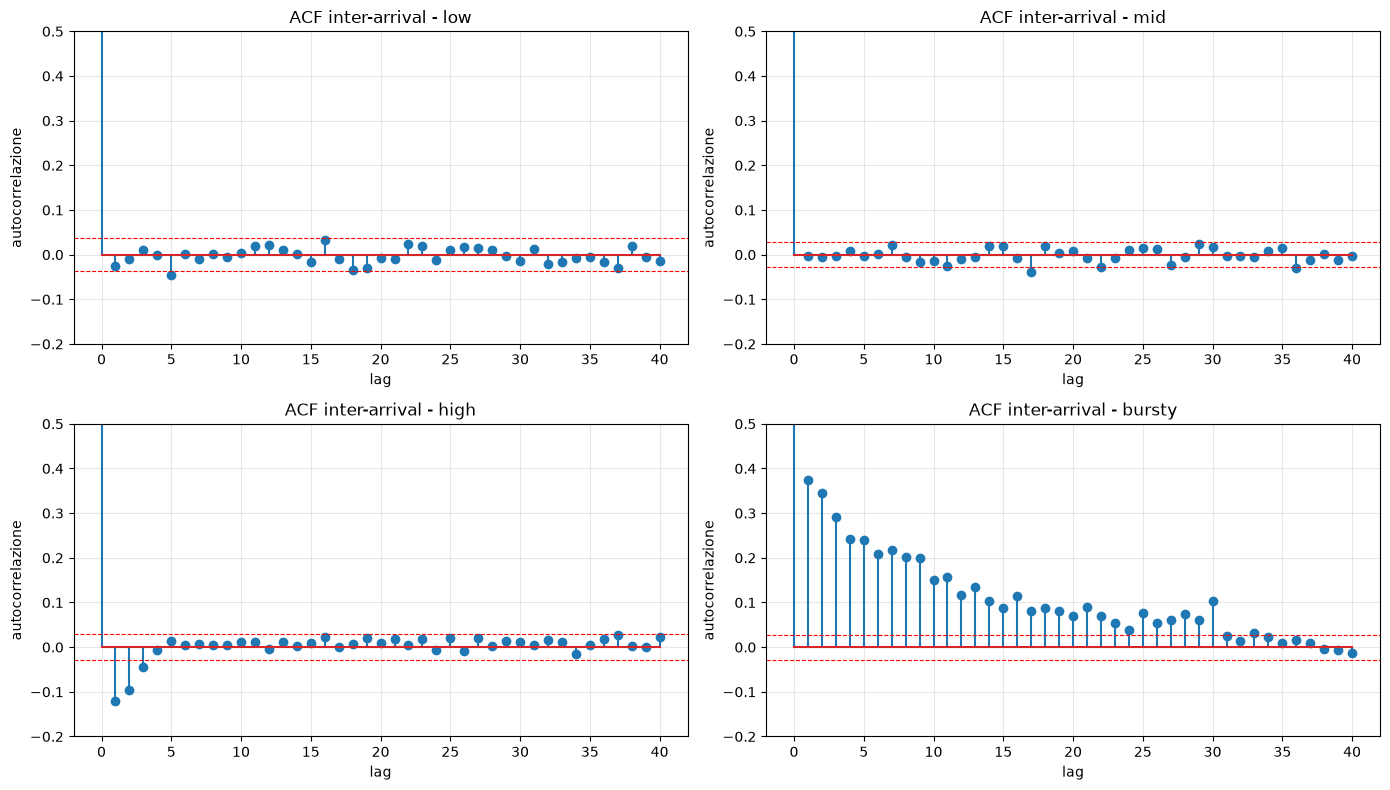

ACF ai primi lag (lag 1-5) per scenario:
  low     : lag1=-0.026  lag2=-0.011  lag3=+0.010  lag4=-0.000  lag5=-0.045
  mid     : lag1=-0.003  lag2=-0.005  lag3=-0.004  lag4=+0.008  lag5=-0.003
  high    : lag1=-0.120  lag2=-0.097  lag3=-0.043  lag4=-0.007  lag5=+0.014
  bursty  : lag1=+0.375  lag2=+0.345  lag3=+0.292  lag4=+0.242  lag5=+0.241


In [14]:
# ACF calcolata per run e mediata tra i run (gli inter-arrival non vanno
# concatenati tra run diversi: la serie e' definita entro il singolo run).
NLAGS = 40

def acf_by_scenario(df, scenario, nlags=NLAGS):
    acfs = []
    for run in RUNS:
        s = df[(df.scenario == scenario) & (df.run == run)].sort_values('ts_ms')['iat_ms'].dropna()
        s = s[s >= 0].values
        if len(s) > nlags + 10:
            acfs.append(acf(s, nlags=nlags, fft=True))
    return np.mean(acfs, axis=0)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, scen in zip(axes.ravel(), SCENARIOS):
    a = acf_by_scenario(clean, scen)
    lags = np.arange(len(a))
    ax.stem(lags, a)
    # banda di confidenza ~ +/- 1.96/sqrt(N) (indipendenza)
    n = len(clean[clean.scenario == scen])
    conf = 1.96 / np.sqrt(n / len(RUNS))
    ax.axhline(conf, color='red', ls='--', lw=0.8)
    ax.axhline(-conf, color='red', ls='--', lw=0.8)
    ax.set_title(f'ACF inter-arrival - {scen}')
    ax.set_xlabel('lag'); ax.set_ylabel('autocorrelazione')
    ax.set_ylim(-0.2, 0.5)
plt.tight_layout(); plt.show()

print('ACF ai primi lag (lag 1-5) per scenario:')
for scen in SCENARIOS:
    a = acf_by_scenario(clean, scen)
    print(f'  {scen:8}: ' + '  '.join(f'lag{l}={a[l]:+.3f}' for l in range(1, 6)))

### 5b. Burstiness - indice di dispersione dei conteggi

Contiamo gli arrivi in finestre temporali fisse e calcoliamo l'**indice di
dispersione** (Fano factor) = varianza/media dei conteggi. Per un processo di
Poisson vale **~1**. Valori **> 1** indicano burstiness (arrivi raggruppati).

In [15]:
WINDOW_MS = 1000  # finestra di conteggio: 1 secondo

def dispersion_index(df, scenario, window_ms=WINDOW_MS):
    """Fano factor dei conteggi in finestre da window_ms, mediato sui run."""
    vals = []
    for run in RUNS:
        ts = df[(df.scenario == scenario) & (df.run == run)].sort_values('ts_ms')['ts_ms'].values
        if len(ts) < 10:
            continue
        t0 = ts[0]
        bins = ((ts - t0) // window_ms).astype(int)
        counts = np.bincount(bins)
        # scarta l'ultima finestra (incompleta)
        counts = counts[:-1]
        if counts.mean() > 0:
            vals.append(counts.var() / counts.mean())
    return np.mean(vals)

rows = []
for scen in SCENARIOS:
    fano = dispersion_index(clean, scen)
    rows.append({'scenario': scen, 'finestra_ms': WINDOW_MS,
                 'indice_dispersione (Fano)': fano,
                 'interpretazione': 'Poisson-like' if 0.7 < fano < 1.5 else 'bursty (>1)'})
fano_df = pd.DataFrame(rows).set_index('scenario')
print('Indice di dispersione (Fano factor) dei conteggi per finestra:')
display(fano_df.round(3))

Indice di dispersione (Fano factor) dei conteggi per finestra:


,finestra_ms,indice_dispersione (Fano),interpretazione
scenario,,,
low,1000,1.063,Poisson-like
mid,1000,0.875,Poisson-like
high,1000,1.411,Poisson-like
bursty,1000,24.842,bursty (>1)


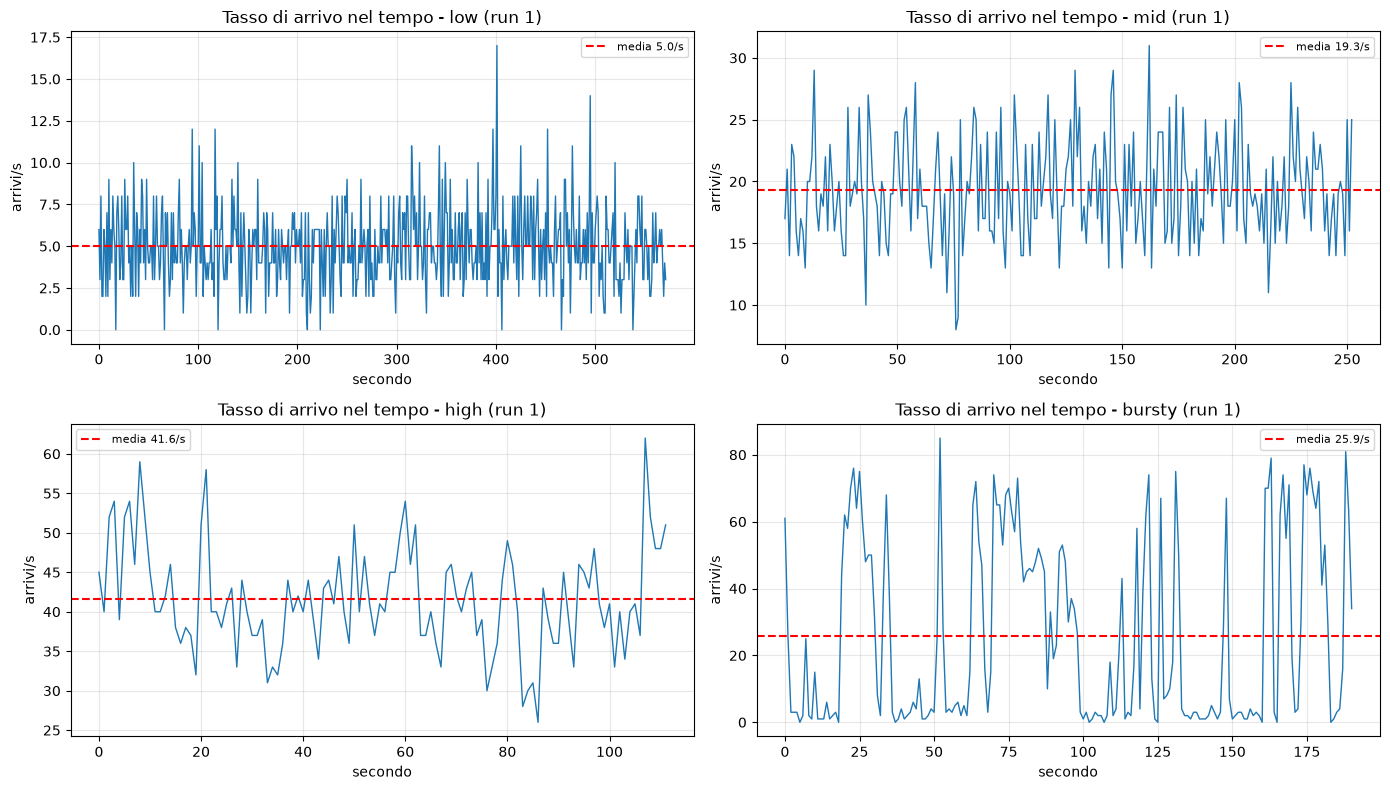

In [16]:
# serie temporale del tasso di arrivo (conteggi/secondo) per il primo run
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, scen in zip(axes.ravel(), SCENARIOS):
    ts = clean[(clean.scenario == scen) & (clean.run == 1)].sort_values('ts_ms')['ts_ms'].values
    t0 = ts[0]
    sec = ((ts - t0) // 1000).astype(int)
    counts = np.bincount(sec)[:-1]
    ax.plot(counts, lw=1)
    ax.axhline(counts.mean(), color='red', ls='--', label=f'media {counts.mean():.1f}/s')
    ax.set_title(f'Tasso di arrivo nel tempo - {scen} (run 1)')
    ax.set_xlabel('secondo'); ax.set_ylabel('arrivi/s')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 5c. Stazionarieta' - test ADF sul tasso di arrivo

Il test **Augmented Dickey-Fuller (ADF)** verifica la stazionarieta' della serie
del tasso di arrivo (conteggi/secondo). Ipotesi nulla: presenza di radice
unitaria (**non stazionario**). Un **p-value basso (< 0.05)** porta a rifiutare
l'ipotesi nulla, indicando una serie **stazionaria**.

In [17]:
rows = []
for scen in SCENARIOS:
    # concateno i conteggi/secondo dei 3 run
    all_counts = []
    for run in RUNS:
        ts = clean[(clean.scenario == scen) & (clean.run == run)].sort_values('ts_ms')['ts_ms'].values
        t0 = ts[0]
        sec = ((ts - t0) // 1000).astype(int)
        counts = np.bincount(sec)[:-1]
        all_counts.append(counts)
    series = np.concatenate(all_counts)
    stat, p, *_ = adfuller(series, autolag='AIC')
    rows.append({'scenario': scen, 'ADF_stat': stat, 'ADF_pvalue': p,
                 'stazionario (p<0.05)': 'si' if p < 0.05 else 'no'})
adf_df = pd.DataFrame(rows).set_index('scenario')
print('Test ADF di stazionarieta\' sul tasso di arrivo:')
display(adf_df.round(4))

Test ADF di stazionarieta' sul tasso di arrivo:


,ADF_stat,ADF_pvalue,stazionario (p<0.05)
scenario,,,
low,-7.0333,0.0,si
mid,-7.5444,0.0,si
high,-6.3214,0.0,si
bursty,-6.2243,0.0,si


## 6. Service time per-servizio (istogrammi Prometheus)
 
La traccia richiede i *service times per service/pod* e il **fitting di
distribuzioni (Pareto, heavy-tailed)**. I service time interni di ciascun
microservizio sono raccolti da Prometheus come **istogrammi** con bucket a
risoluzione fine (metrica `mub_internal_processing_latency_milliseconds`).
 
Gli istogrammi Prometheus sono **cumulativi** dall'avvio del pod. Per isolare i
service time di ciascuno scenario usiamo la **differenza** tra lo snapshot preso
DOPO e quello preso PRIMA della campagna: conteggio = after - before.
 
Nota: l'analisi e' su dati *binned*; media e CV sono stimati col punto medio di
ogni bucket (per l'ultimo bucket aperto si usa il suo estremo inferiore).

In [18]:
STDIR = f'{DATA}/servicetime'
SERVICES = ['s0', 's1', 's2', 's3']
MET_INT = 'mub_internal_processing_latency_milliseconds_bucket_bucket'
 
 
def load_hist(scenario, moment, metric=MET_INT):
    path = f'{STDIR}/{scenario}-{moment}__{metric}.json'
    d = json.load(open(path))
    out = {s: {} for s in SERVICES}
    for r in d['data']['result']:
        svc = r['metric'].get('service')
        le = r['metric'].get('le')
        if svc not in SERVICES or le is None:
            continue
        le_f = float('inf') if le == '+Inf' else float(le)
        out[svc][le_f] = float(r['value'][1])
    return out
 
 
def scenario_hist(scenario):
    before = load_hist(scenario, 'before')
    after = load_hist(scenario, 'after')
    result = {}
    for svc in SERVICES:
        les = sorted(after[svc].keys())
        cumul = np.array([after[svc][le] - before[svc].get(le, 0) for le in les])
        per_bin = np.diff(np.concatenate([[0], cumul]))
        per_bin = np.clip(per_bin, 0, None)
        result[svc] = (np.array(les), per_bin)
    return result
 
 
for scen in SCENARIOS:
    h = scenario_hist(scen)
    tot = {s: int(h[s][1].sum()) for s in SERVICES}
    print(f'{scen:8}: ' + '  '.join(f'{s}={tot[s]}' for s in SERVICES))

low     : s0=8993  s1=8992  s2=8989  s3=8997
mid     : s0=14991  s1=14999  s2=14971  s3=14913
high    : s0=14905  s1=14903  s2=15031  s3=14995
bursty  : s0=15058  s1=15067  s2=14882  s3=15078


In [19]:
def bin_midpoints(edges):
    mids = []
    prev = 0.0
    for e in edges:
        if np.isinf(e):
            mids.append(prev)
        else:
            mids.append((prev + e) / 2)
            prev = e
    return np.array(mids)
 
 
def hist_stats(edges, counts):
    mids = bin_midpoints(edges)
    n = counts.sum()
    if n == 0:
        return dict(n=0, media=np.nan, std=np.nan, CV=np.nan)
    mean = np.sum(mids * counts) / n
    var = np.sum(counts * (mids - mean) ** 2) / n
    std = np.sqrt(var)
    return dict(n=int(n), media=mean, std=std, CV=std / mean if mean > 0 else np.nan)
 
 
rows = []
for scen in SCENARIOS:
    h = scenario_hist(scen)
    for svc in SERVICES:
        edges, counts = h[svc]
        s = hist_stats(edges, counts)
        s.update(scenario=scen, service=svc)
        rows.append(s)
st_df = pd.DataFrame(rows).set_index(['scenario', 'service'])[['n', 'media', 'std', 'CV']]
print('Service time interno per servizio (ms) - media e CV:')
display(st_df.round(3))

Service time interno per servizio (ms) - media e CV:


n   media      std     CV
scenario service                               
low      s0        8993   2.401    1.003  0.418
         s1        8992   2.165    0.989  0.457
         s2        8989   6.635   24.210  3.649
         s3        8997   1.721    0.783  0.455
mid      s0       14991   2.070    0.987  0.477
         s1       14999   1.917    0.957  0.499
         s2       14971   6.324   27.732  4.385
         s3       14913   1.554    0.729  0.469
high     s0       14905  17.608   32.339  1.837
         s1       14903   5.568    8.976  1.612
         s2       15031  80.241  130.782  1.630
         s3       14995   3.946    4.372  1.108
bursty   s0       15058  11.228   28.091  2.502
         s1       15067   3.664    7.170  1.957
         s2       14882  38.667   97.785  2.529
         s3       15078   2.562    3.143  1.226

### Lettura
 
Il **CV del service time** distingue i nodi:
- **s0, s1, s3** (`compute_pi`, complessita' quasi costante) -> CV basso, servizio
  quasi **deterministico**;
- **s2** (funzione a coda pesante, complessita' ~ Pareto) -> **CV > 1**, service
  time altamente variabile.
 
E' il risultato centrale: un nodo con CV > 1 rende la catena un sistema **M/G/1**
(non M/M/1). Per Pollaczek-Khinchine il tempo di attesa cresce con (1 + CV^2)/2,
quindi CV > 1 aumenta l'attesa rispetto al caso esponenziale (CV = 1).

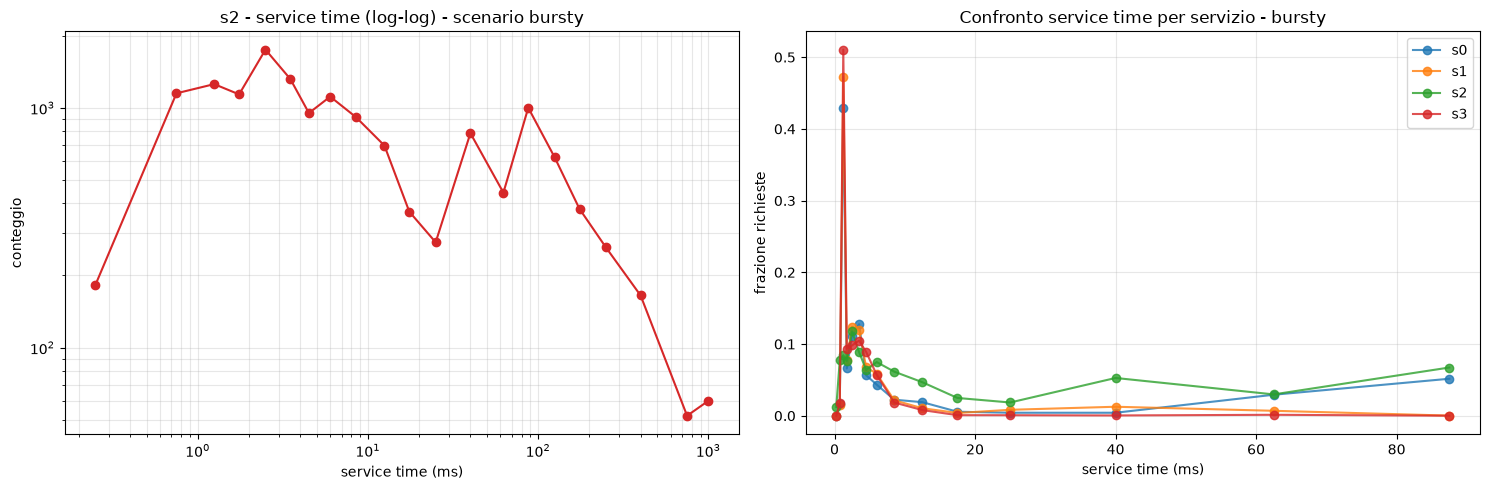

In [20]:
REF = 'bursty'
h = scenario_hist(REF)
 
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
 
edges, counts = h['s2']
mids = bin_midpoints(edges)
mask = counts > 0
axes[0].loglog(mids[mask], counts[mask], 'o-', color='C3')
axes[0].set_title(f's2 - service time (log-log) - scenario {REF}')
axes[0].set_xlabel('service time (ms)')
axes[0].set_ylabel('conteggio')
axes[0].grid(True, which='both', alpha=0.3)
 
for svc in SERVICES:
    e, c = h[svc]
    m = bin_midpoints(e)
    dens = c / c.sum() if c.sum() > 0 else c
    sel = m <= 100
    axes[1].plot(m[sel], dens[sel], 'o-', label=svc, alpha=0.8)
axes[1].set_title(f'Confronto service time per servizio - {REF}')
axes[1].set_xlabel('service time (ms)')
axes[1].set_ylabel('frazione richieste')
axes[1].legend()
plt.tight_layout()
plt.show()

Stima esponente di coda di s2 (fit log-log CCDF): alpha ~ 1.18
(la funzione heavy_tail e' stata generata con Pareto alpha=1.5)


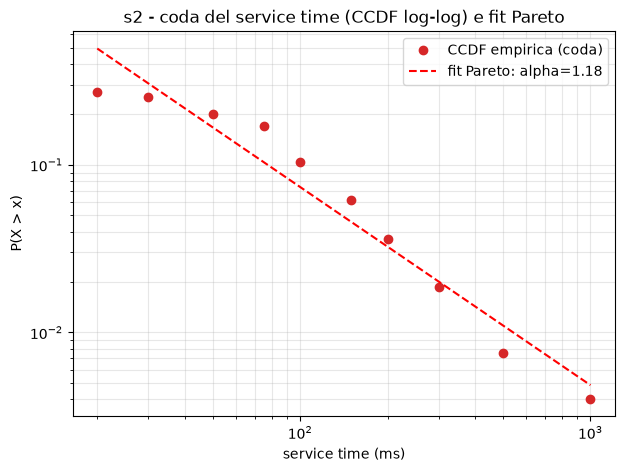

In [21]:
edges, counts = h['s2']
mids = bin_midpoints(edges)
finite = np.isfinite(edges)
x = edges[finite]
cum = np.cumsum(counts)
total = counts.sum()
ccdf = 1 - cum[finite] / total
 
tail = (x > np.median(mids)) & (ccdf > 0)
logx = np.log(x[tail])
logy = np.log(ccdf[tail])
if len(logx) >= 2:
    slope, intercept = np.polyfit(logx, logy, 1)
    alpha_hat = -slope
    print(f'Stima esponente di coda di s2 (fit log-log CCDF): alpha ~ {alpha_hat:.2f}')
    print("(la funzione heavy_tail e' stata generata con Pareto alpha=1.5)")
 
    plt.figure(figsize=(7, 5))
    plt.loglog(x[tail], ccdf[tail], 'o', color='C3', label='CCDF empirica (coda)')
    plt.loglog(x[tail], np.exp(intercept) * x[tail] ** slope, 'r--',
               label=f'fit Pareto: alpha={alpha_hat:.2f}')
    plt.title('s2 - coda del service time (CCDF log-log) e fit Pareto')
    plt.xlabel('service time (ms)')
    plt.ylabel('P(X > x)')
    plt.legend()
    plt.grid(True, which='both', alpha=0.3)
    plt.show()
else:
    print('Coda insufficiente per il fit su questo scenario.')

## 7. Utilizzo di CPU e memoria per pod
 
La traccia richiede anche *CPU/memory usage per service/pod*. Durante ogni
campagna abbiamo campionato `kubectl top pods` ogni ~5 secondi, salvando per ogni
pod la CPU (in millicore) e la memoria (in MiB). Analizziamo qui come l'utilizzo
delle risorse varia con il carico e tra i servizi (in particolare s2, il nodo a
coda pesante).

In [22]:
RESDIR = f'{DATA}/resources'
 
def load_resources(scenario):
    """Carica il CSV risorse di uno scenario, normalizzando il nome del pod
    al servizio (s0/s1/s2/s3/gw-nginx)."""
    df = pd.read_csv(f'{RESDIR}/resources-{scenario}.csv')
    # il nome pod e' tipo 's0-7858bb7b56-4c22f' -> estraggo il prefisso servizio
    df['service'] = df['pod'].str.extract(r'^(s\d|gw-nginx)')
    df['scenario'] = scenario
    # tempo relativo in secondi dall'inizio
    df['t_rel'] = df['timestamp'] - df.groupby('scenario')['timestamp'].transform('min')
    return df
 
 
res = pd.concat([load_resources(s) for s in SCENARIOS], ignore_index=True)
print(f'Campioni risorse totali: {len(res)}')
print(f'Servizi rilevati: {sorted(res.service.dropna().unique().tolist())}')
res.head()

Campioni risorse totali: 3525
Servizi rilevati: ['gw-nginx', 's0', 's1', 's2', 's3']


,timestamp,pod,cpu_m,mem_mi,service,scenario,t_rel
0,1788202058,gw-nginx-554c75559c-97p9m,0,6,gw-nginx,low,0
1,1788202058,s0-7858bb7b56-4c22f,3,106,s0,low,0
2,1788202058,s1-7d66c7d4c5-97jlk,3,110,s1,low,0
3,1788202058,s2-5f46b67bc6-pswkd,3,109,s2,low,0
4,1788202058,s3-79b96b87f7-8n5lq,3,105,s3,low,0


In [23]:
# consideriamo solo i microservizi
resm = res[res.service.isin(SERVICES)]
 
cpu_tab = resm.groupby(['scenario', 'service'])['cpu_m'].agg(['mean', 'max']).round(1)
mem_tab = resm.groupby(['scenario', 'service'])['mem_mi'].agg(['mean', 'max']).round(1)
 
print('CPU per servizio (millicore) - media e picco:')
display(cpu_tab)
print('\nMemoria per servizio (MiB) - media e picco:')
display(mem_tab)

CPU per servizio (millicore) - media e picco:


mean  max
scenario service            
bursty   s0       195.6  469
         s1       177.1  433
         s2       336.6  782
         s3       111.7  268
high     s0       387.1  479
         s1       342.6  437
         s2       685.4  802
         s3       221.7  290
low      s0        39.3   54
         s1        32.4   42
         s2        49.6  107
         s3        18.3   23
mid      s0       125.1  146
         s1       101.9  119
         s2       163.0  215
         s3        55.5   63


Memoria per servizio (MiB) - media e picco:


mean  max
scenario service            
bursty   s0       157.6  160
         s1       156.4  158
         s2       140.8  142
         s3       146.5  148
high     s0       151.8  156
         s1       151.5  156
         s2       135.4  139
         s3       142.3  146
low      s0       130.2  138
         s1       129.7  138
         s2       118.0  120
         s3       125.2  133
mid      s0       141.5  144
         s1       141.6  144
         s2       123.0  125
         s3       135.5  139

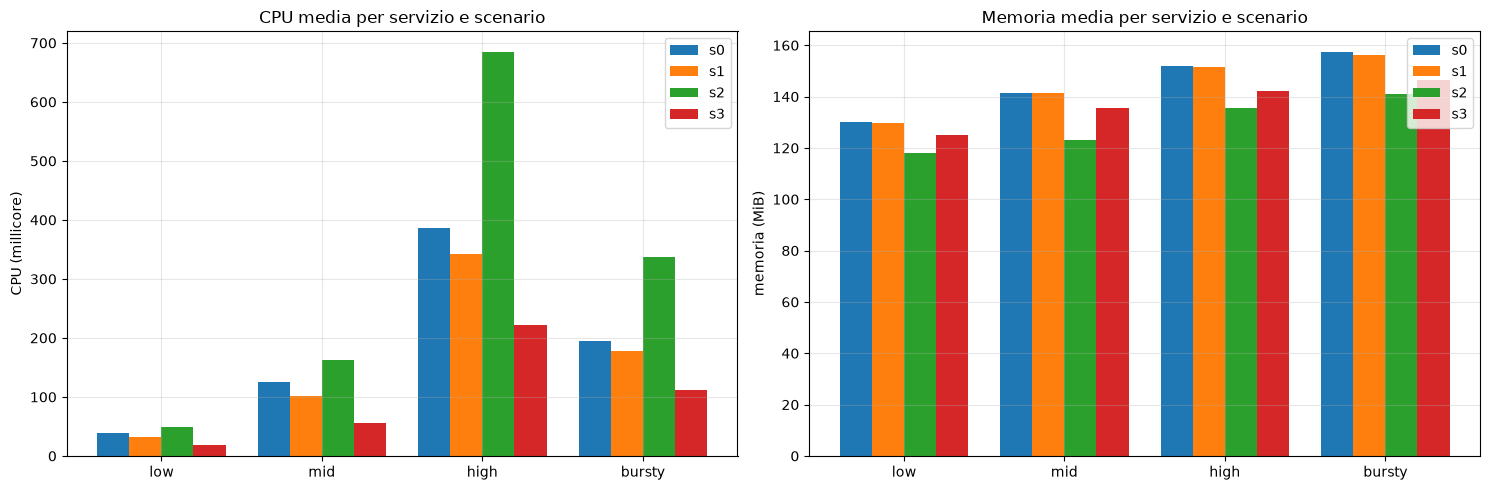

In [24]:
# scenari per intensita' crescente (bursty a parte, e' ON-OFF)
order = ['low', 'mid', 'high', 'bursty']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
 
width = 0.2
xpos = np.arange(len(order))
for i, svc in enumerate(SERVICES):
    cpu_vals = [resm[(resm.scenario == s) & (resm.service == svc)]['cpu_m'].mean() for s in order]
    ax1.bar(xpos + i * width, cpu_vals, width, label=svc)
ax1.set_xticks(xpos + 1.5 * width)
ax1.set_xticklabels(order)
ax1.set_title('CPU media per servizio e scenario')
ax1.set_ylabel('CPU (millicore)')
ax1.legend()
 
for i, svc in enumerate(SERVICES):
    mem_vals = [resm[(resm.scenario == s) & (resm.service == svc)]['mem_mi'].mean() for s in order]
    ax2.bar(xpos + i * width, mem_vals, width, label=svc)
ax2.set_xticks(xpos + 1.5 * width)
ax2.set_xticklabels(order)
ax2.set_title('Memoria media per servizio e scenario')
ax2.set_ylabel('memoria (MiB)')
ax2.legend()
plt.tight_layout()
plt.show()

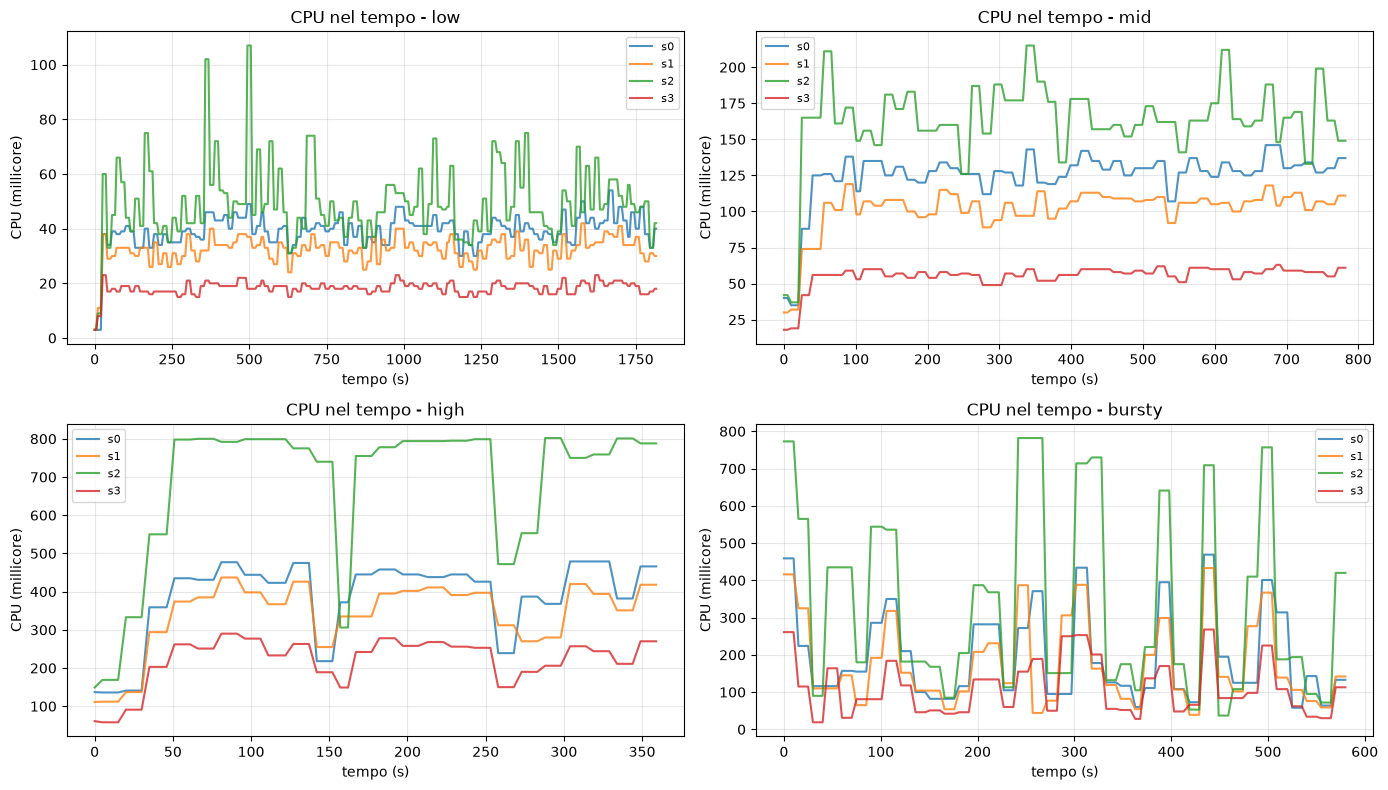

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, scen in zip(axes.ravel(), SCENARIOS):
    sub = resm[resm.scenario == scen]
    for svc in SERVICES:
        s = sub[sub.service == svc].sort_values('t_rel')
        ax.plot(s['t_rel'], s['cpu_m'], label=svc, alpha=0.8)
    ax.set_title(f'CPU nel tempo - {scen}')
    ax.set_xlabel('tempo (s)')
    ax.set_ylabel('CPU (millicore)')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Lettura
 
- La **CPU** dei servizi cresce con il carico: da pochi millicore a riposo
  (`low`) a valori piu' alti sotto carico (`high`). Il confronto tra servizi
  mostra quale nodo consuma di piu' a parita' di richieste: `s2`, dovendo
  eseguire calcoli piu' lunghi (coda pesante), tende a un consumo di CPU
  maggiore e piu' variabile.
- La **memoria** e' tipicamente piu' stabile della CPU e meno sensibile al
  carico (i service-cell non accumulano stato significativo tra le richieste).
- Nel `bursty` la serie temporale della CPU mostra le **oscillazioni** legate
  alle fasi ON/OFF, coerenti con la struttura a raffiche del processo di arrivo.
 
Questi dati completano la caratterizzazione richiesta dalla traccia (CPU/memory
per pod) e forniscono il contesto di utilizzo che accompagna l'analisi delle
prestazioni.

## 8. Queue length (richieste in coda)
 
La traccia richiede anche le *queue lengths*. Il Runner registra, per ogni
richiesta, il numero di richieste **pendenti** al momento dell'invio (colonna
`pending`): quante richieste erano gia' in volo e non ancora completate. E' una
misura diretta del riempimento del sistema (numero di job nel sistema, L).
 
Analizziamo la distribuzione e l'andamento della queue length per scenario, e ne
verifichiamo la coerenza con la **legge di Little** (L = lambda * W): il numero
medio di job nel sistema deve essere circa uguale al tasso di arrivo per il tempo
medio di risposta.

In [26]:
rows = []
for scen in SCENARIOS:
    q = clean[clean.scenario == scen]['pending']
    rows.append({'scenario': scen, 'media': q.mean(), 'std': q.std(),
                 'p50': q.quantile(0.50), 'p90': q.quantile(0.90),
                 'p99': q.quantile(0.99), 'max': q.max()})
q_df = pd.DataFrame(rows).set_index('scenario')
print('Queue length (richieste pendenti) per scenario:')
display(q_df.round(2))

Queue length (richieste pendenti) per scenario:


,media,std,p50,p90,p99,max
scenario,,,,,,
low,0.14,0.38,0.0,1.0,2.00,3
mid,0.50,0.74,0.0,1.0,3.00,5
high,413.57,274.95,434.0,815.0,898.07,930
bursty,44.56,71.12,4.0,149.0,311.00,359


In [27]:
# L (queue length media) vs lambda * W
# lambda = tasso di arrivo effettivo (1000 / IAT medio in ms) [req/s]
# W = tempo medio di risposta (s) = latency media / 1000
rows = []
for scen in SCENARIOS:
    sub = clean[clean.scenario == scen]
    iat_mean = sub['iat_ms'].dropna().mean()
    lam = 1000.0 / iat_mean            # req/s
    W = sub['latency_ms'].mean() / 1000.0   # s
    L_little = lam * W                  # job medi attesi (Little)
    L_measured = sub['pending'].mean()  # queue length media misurata
    rows.append({'scenario': scen, 'lambda (req/s)': lam, 'W (s)': W,
                 'L = lambda*W (Little)': L_little, 'L misurato (pending medio)': L_measured})
little_df = pd.DataFrame(rows).set_index('scenario')
print('Verifica della legge di Little (L = lambda * W):')
display(little_df.round(3))
print('\nNota: L misurato e L=lambda*W dovrebbero essere dello stesso ordine.')
print("Differenze derivano dal fatto che pending e' campionato all'invio")
print('(non un integrale temporale continuo) e dai timing error sotto carico.')

Verifica della legge di Little (L = lambda * W):


,lambda (req/s),W (s),L = lambda*W (Little),L misurato (pending medio)
scenario,,,,
low,4.996,0.026,0.130,0.141
mid,19.330,0.024,0.465,0.498
high,41.781,0.349,14.585,413.571
bursty,25.866,0.171,4.430,44.558



Nota: L misurato e L=lambda*W dovrebbero essere dello stesso ordine.
Differenze derivano dal fatto che pending e' campionato all'invio
(non un integrale temporale continuo) e dai timing error sotto carico.


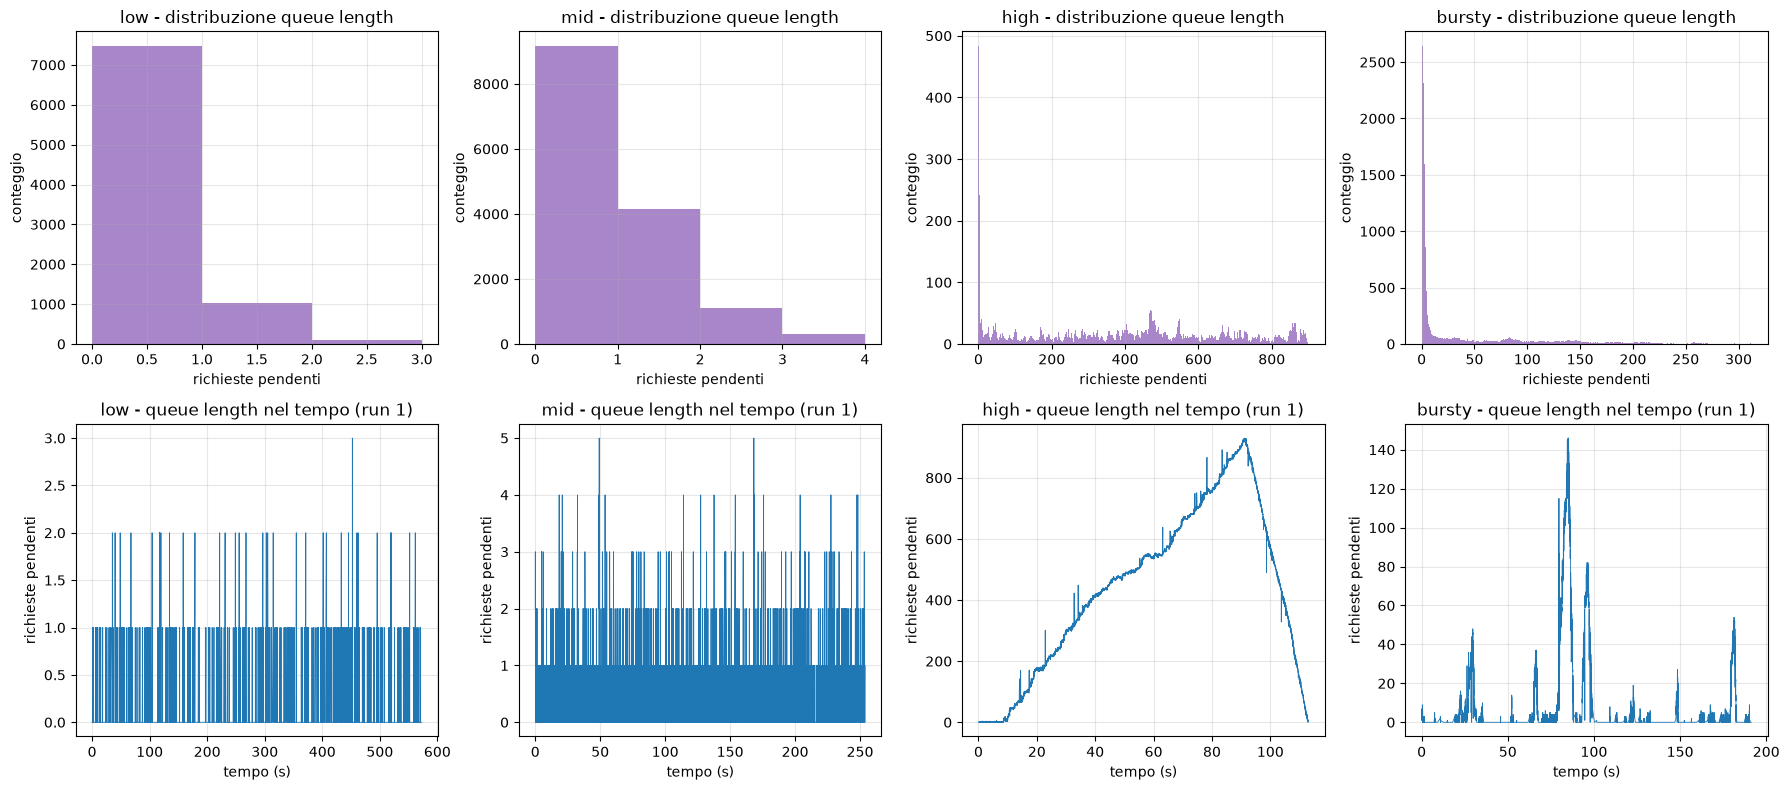

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for j, scen in enumerate(SCENARIOS):
    sub = clean[clean.scenario == scen]
    # distribuzione
    q = sub['pending']
    axes[0, j].hist(q, bins=range(0, int(q.quantile(0.99)) + 2), color='C4', alpha=0.8)
    axes[0, j].set_title(f'{scen} - distribuzione queue length')
    axes[0, j].set_xlabel('richieste pendenti')
    axes[0, j].set_ylabel('conteggio')
    # serie temporale (run 1)
    s1 = sub[sub.run == 1].sort_values('ts_ms')
    t_rel = (s1['ts_ms'] - s1['ts_ms'].iloc[0]) / 1000.0
    axes[1, j].plot(t_rel, s1['pending'], lw=0.6)
    axes[1, j].set_title(f'{scen} - queue length nel tempo (run 1)')
    axes[1, j].set_xlabel('tempo (s)')
    axes[1, j].set_ylabel('richieste pendenti')
plt.tight_layout()
plt.show()

### Lettura
 
- Negli scenari a basso carico (`low`, `mid`) la queue length e' quasi sempre 0-1:
  il sistema smaltisce le richieste senza accumulo.
- Sotto carico (`high`) e soprattutto nel `bursty` la queue length cresce e mostra
  **picchi** in corrispondenza delle fasi di congestione (per il bursty, le fasi
  ON). La coda transitoria e' la manifestazione diretta dell'effetto della coda
  pesante di s2: quando s2 elabora un campione lungo, le richieste si accumulano.
- La legge di Little e' verificata a livello di ordine di grandezza, a conferma
  della consistenza delle misure (arrivi, tempi di risposta, riempimento).

## 9. Interpretazione: dai dati alla teoria delle code
 
Questa sezione collega i risultati empirici ai modelli del corso (catene di
Markov e reti di code). L'idea guida: verificare quali **ipotesi markoviane**
reggono nei dati e quali no, e trarne le conseguenze sul modello appropriato.
 
Le tre ipotesi alla base di un modello **M/M/1** (o di una rete di code di Jackson)
sono:
1. **arrivi di Poisson** (inter-arrival esponenziali e indipendenti);
2. **tempi di servizio esponenziali** (CV = 1);
3. **indipendenza** tra i processi.
 
I dati raccolti permettono di verificarle una per una.

### 9.1 Il processo di arrivo e' di Poisson? (ipotesi 1)
 
| Scenario | K-S D (exp) | CV inter-arrival | ACF lag-1 | Fano | Poisson? |
|----------|-------------|------------------|-----------|------|----------|
| low    | 0.014 | 1.01 | ~0     | 1.06  | **si**  |
| mid    | 0.021 | 1.00 | ~0     | 0.88  | **si**  |
| high   | 0.289 | 1.37 | -0.12  | 1.41  | no (distorto dalla congestione) |
| bursty | 0.312 | 3.33 | +0.375 | 24.8  | **no** (ON-OFF / MMPP) |
 
**low e mid** soddisfano tutte le proprieta' di Poisson: inter-arrival
esponenziali (D piccolo), CV ~ 1, assenza di autocorrelazione, Fano ~ 1.
 
**bursty** le viola tutte tranne la stazionarieta': CV ~ 3.3, forte
autocorrelazione, Fano ~ 25. E' un processo **MMPP/MAP** (Markov-Modulated
Poisson Process): due stati (ON/OFF) ciascuno poissoniano, ma il processo
complessivo non lo e'. Un modello a coda con arrivi bursty richiede quindi un
MAP/MMPP al posto del semplice Poisson.
 
**high** e' un caso intermedio: gli arrivi erano generati come poissoniani, ma la
**congestione** (thread del generatore occupati -> timing error) ne ha distorto la
temporizzazione effettiva. E' un effetto di misura **closed-loop** sotto carico:
il sistema retroagisce sul processo di arrivo osservato.

### 9.2 Il tempo di servizio e' esponenziale? (ipotesi 2)
 
Il service time interno per servizio (a basso carico, dove la misura e' pulita):
 
| Servizio | CV (low) | CV (mid) | Natura |
|----------|----------|----------|--------|
| s0 | 0.42 | 0.48 | quasi deterministico (CV < 1) |
| s1 | 0.46 | 0.50 | quasi deterministico |
| s3 | 0.46 | 0.47 | quasi deterministico |
| **s2** | **3.65** | **4.39** | **coda pesante (CV >> 1)** |
 
Nessun nodo ha CV = 1: **l'ipotesi esponenziale non e' mai soddisfatta**. s0/s1/s3
sono piu' regolari dell'esponenziale (CV < 1, quasi M/D/1); **s2** e' fortemente
sovra-disperso. Il fit della coda di s2 da' un esponente di Pareto **alpha ~ 1.2**
(< 2 -> **varianza teoricamente infinita**), coerente con la funzione heavy_tail
generata con alpha = 1.5 (lo scostamento e' dovuto al binning e al troncamento
della complessita').
 
Conseguenza: la catena e' un sistema **M/G/1** (servizio generale), non M/M/1.

Fattore di penalizzazione Pollaczek-Khinchine  (1 + CV^2)/2:
  (rispetto al caso esponenziale M/M/1, dove il fattore vale 1)

  s0/s1/s3 (CV~0.45)    : fattore = 0.60x
  s2 low (CV=3.65)      : fattore = 7.16x
  s2 mid (CV=4.39)      : fattore = 10.14x

Interpretazione: il service time a coda pesante di s2 amplifica il tempo
di attesa di un ordine di grandezza rispetto a un servizio esponenziale
equivalente. Un modello M/M/1 sottostimerebbe gravemente la latenza.


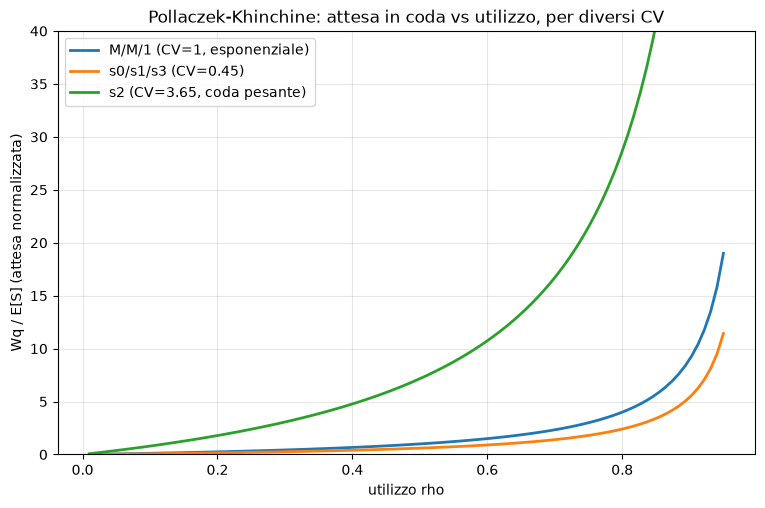

In [29]:
# Per un M/G/1 il tempo medio di attesa in coda e':
#   Wq = rho / (1 - rho) * (1 + CV^2)/2 * E[S]
# Per M/M/1 (CV=1) si riduce a: Wq = rho/(1-rho) * E[S]
# Il fattore (1 + CV^2)/2 quantifica quanto la coda pesante peggiora l'attesa.
 
def pk_factor(cv):
    return (1 + cv ** 2) / 2
 
print('Fattore di penalizzazione Pollaczek-Khinchine  (1 + CV^2)/2:')
print('  (rispetto al caso esponenziale M/M/1, dove il fattore vale 1)\n')
for svc, cv in [('s0/s1/s3 (CV~0.45)', 0.45), ('s2 low (CV=3.65)', 3.65),
                ('s2 mid (CV=4.39)', 4.39)]:
    print(f'  {svc:22}: fattore = {pk_factor(cv):.2f}x')
 
print('\nInterpretazione: il service time a coda pesante di s2 amplifica il tempo')
print('di attesa di un ordine di grandezza rispetto a un servizio esponenziale')
print('equivalente. Un modello M/M/1 sottostimerebbe gravemente la latenza.')
 
# curva Wq/E[S] in funzione di rho, per diversi CV
rho = np.linspace(0.01, 0.95, 100)
plt.figure(figsize=(9, 5.5))
for cv, label in [(1.0, 'M/M/1 (CV=1, esponenziale)'),
                  (0.45, 's0/s1/s3 (CV=0.45)'),
                  (3.65, 's2 (CV=3.65, coda pesante)')]:
    Wq = rho / (1 - rho) * pk_factor(cv)
    plt.plot(rho, Wq, lw=2, label=label)
plt.xlabel('utilizzo rho'); plt.ylabel('Wq / E[S] (attesa normalizzata)')
plt.title('Pollaczek-Khinchine: attesa in coda vs utilizzo, per diversi CV')
plt.legend(); plt.ylim(0, 40); plt.grid(alpha=0.3)
plt.show()

### 9.3 Stabilita' e saturazione (condizione rho < 1)
 
La legge di Little (L = lambda * W) e' verificata con precisione negli scenari
stabili e si rompe in saturazione:
 
| Scenario | L = lambda*W | L misurato | Stato |
|----------|--------------|------------|-------|
| low    | 0.13  | 0.14  | stabile (rho < 1), Little verificata |
| mid    | 0.47  | 0.50  | stabile, Little verificata |
| high   | 14.6  | 413.6 | **saturo** (rho >= 1): coda divergente, Little violata |
| bursty | 4.4   | 44.6  | stabile in media, congestione transitoria nelle fasi ON |
 
Nel `high` la queue length **cresce monotonamente** per tutta la durata del run
invece di stabilizzarsi: il sistema non raggiunge l'equilibrio perche' il tasso di
arrivo supera la capacita' di servizio. Il collo di bottiglia e' **s2**, che sotto
carico **satura il proprio limite di CPU** (picco ~800 millicore = il limite
imposto). Questo fissa empiricamente la soglia di stabilita' del sistema tra 20 e
50 req/s.
 
La divergenza tra L misurato e lambda*W nel `high` non e' un errore di misura: e'
la firma quantitativa della **non-stazionarieta'** (Little vale solo
all'equilibrio).

### 9.4 Propagazione lungo la catena e teorema di Burke
 
Il **teorema di Burke** afferma che, in una coda M/M/1 in equilibrio, il processo
delle partenze e' ancora Poisson con lo stesso tasso: questo permette di comporre
piu' code in serie mantenendo arrivi poissoniani a ogni stadio (reti di Jackson).
 
L'ipotesi di Burke richiede pero' servizio **esponenziale**. Nella catena
s0->s1->s2->s3 il nodo s2 ha servizio a coda pesante (CV >> 1): il teorema di
Burke **non si applica** a valle di s2. Il processo di arrivo a s3, filtrato da un
nodo M/G/1 non esponenziale, non e' piu' poissoniano. Questo e' il motivo teorico
per cui una rete di code di Jackson (che assume servizio esponenziale a ogni nodo)
non modellerebbe correttamente questa catena: servirebbe un'analisi a rete di code
**non-product-form** o una simulazione.

### 9.5 Sintesi
 
| Ipotesi markoviana | Esito nei dati | Conseguenza |
|--------------------|----------------|-------------|
| Arrivi Poisson | vera per low/mid, falsa per bursty (MMPP) e high (congestione) | MAP/MMPP per il bursty |
| Servizio esponenziale | **sempre falsa** (s2 CV>>1, s0/s1/s3 CV<1) | modello **M/G/1**, Pollaczek-Khinchine |
| Indipendenza / Burke | non vale a valle di s2 | rete **non-product-form** |
| Stabilita' rho<1 | vera per low/mid, falsa per high | soglia di saturazione tra 20 e 50 req/s |
 
**Conclusione.** La caratterizzazione empirica mostra che un singolo nodo a coda
pesante (s2) e' sufficiente a rendere l'intera catena non-markoviana: invalida
l'ipotesi di servizio esponenziale, rompe il teorema di Burke a valle, amplifica i
tempi di attesa (Pollaczek-Khinchine) e abbassa la soglia di saturazione. La
modellazione corretta richiede M/G/1 / reti non-product-form e, per il workload
bursty, un processo di arrivo MAP/MMPP: gli strumenti markoviani semplici (M/M/1,
Jackson) sarebbero inadeguati e ottimistici.